In [39]:
import json

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from flask import Flask, request, jsonify
from flask_cors import CORS

import torch
import torch.nn as nn
from torchvision.transforms import transforms
torch.__version__

'2.11.0+cpu'

In [40]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

In [41]:
model = nn.Sequential(
    nn.Flatten(),

    # layer 1
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Dropout(0.20),

    # layer 2
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.20),

    # layer 3
    nn.Linear(64, 10),
)

In [42]:
model.load_state_dict(torch.load('mnist-model.pth'))

<All keys matched successfully>

In [43]:
def print_pixel_grid(grid):
  for row in grid:
    if isinstance(row, torch.Tensor):
      row = ((row + 1) * 127.5).to(int)
    print(' '.join(map(lambda x: f'{x:>3}', row)))

In [44]:
# batch has just 1 image, NOT 32
batch = torch.tensor([[[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -0.7020,
                         -0.1137,  0.6235,  0.9843,  1.0000,  0.9843,  0.1216, -0.7020,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -0.7020,  0.7176,
                         0.9765,  0.9765,  0.9765,  0.9843,  0.9765,  0.9765,  0.8353,
                         0.1451, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000,  0.4980,  0.9765,
                         0.8745,  0.4118, -0.5686,  0.5373,  0.6784,  0.9765,  0.9765,
                         0.9765, -0.5529, -0.9529, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -0.2078,  0.3804,
                         -0.4902, -1.0000, -1.0000, -1.0000, -0.7804,  0.5608,  0.9765,
                         0.9765,  0.9843, -0.6627, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -0.8039,  0.6078,
                         0.9765,  0.9843,  0.3098, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -0.7725,
                         0.9843,  1.0000,  0.9843,  0.5373, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -0.9765,
                         -0.1686,  0.9843,  0.9765,  0.9294, -0.4118, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000,  0.7412,  0.9765,  0.9765, -0.3412, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -0.2078,  0.9529,  0.9765, -0.3412, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -0.3804, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000,  0.7647,  0.9765, -0.3412, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -0.8980,  0.4980,  1.0000,  0.3176, -1.0000, -1.0000,
                         -1.0000, -1.0000,  0.2784,  0.9843,  0.7647, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000,  0.2078,  0.9765,  0.9843,  0.9059, -0.6078, -1.0000,
                         -1.0000, -1.0000, -0.3333,  0.9765,  0.7490, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000,  0.3255,  0.9765,  0.9843,  0.9765, -0.5686, -1.0000,
                         -1.0000, -1.0000, -0.3333,  0.9765,  0.7490, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -0.4353,  0.8745,  0.9843,  0.9765,  0.4667, -0.5608,
                         -1.0000, -1.0000,  0.3961,  0.9765,  0.7490, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000,  0.0980,  0.9843,  0.9765,  0.9765,  0.3882,
                         -0.5059, -1.0000,  0.7647,  0.9765,  0.1373, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000,  0.1059,  1.0000,  0.9843,  0.9843,  0.9843,
                         0.9843,  0.3804,  0.9843,  0.9843, -0.3412, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -0.8824,  0.9843,  0.9765,  0.9765,  0.9765,
                         0.9765,  0.9843,  0.9765,  0.9765, -0.3412, -1.0000, -1.0000,
                         -0.7725, -0.4824, -0.5529, -0.3333, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000,  0.5373,  0.9294,  0.9765,  0.9765,
                         0.9765,  0.9843,  0.9765,  0.9765,  0.6863,  0.5451,  0.5529,
                         0.6863,  0.8745,  0.8353,  0.7255, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000,  0.0196,  0.9765,  0.9765,
                         0.9765,  0.7647,  0.9529,  0.9765,  0.9765,  0.9765,  0.9843,
                         0.9765,  0.9216,  0.6314, -0.7098, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -0.7020, -0.1216, -0.1216,
                         -0.1216, -1.0000, -0.2157, -0.1216, -0.1216, -0.1216, -0.1216,
                         -0.1216, -0.3176, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000]]]])

torch.Size([1, 1, 28, 28])

(tensor(-1.), tensor(1.))

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0  37 113 206 252 255 252 143  37   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0  37 218 252 252 252 252 252 252 234 146   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0 190 252 238 180  55 196 213 252 252 252  57   6   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0 101 176  64   0   0   0  27 199 252 252 252  43   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0  25 204 252 252 166   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0  29 252 255 252 196   0   0   0   0   0   0   0   0 

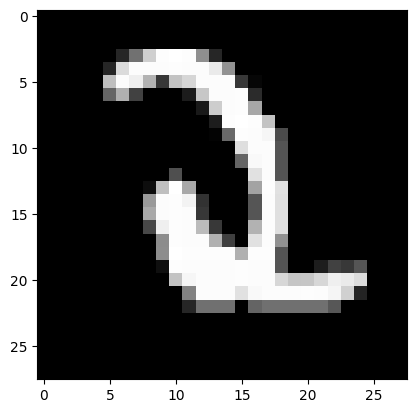

In [45]:
batch.shape
batch.min(), batch.max()
print_pixel_grid(batch[0, 0])
_ = plt.imshow(batch[0, 0], cmap='gray')

In [46]:
_ = model.eval()
with torch.no_grad():
  outputs = model(batch)
  torch.max(outputs, dim=1).indices

tensor([2])

In [47]:
app = Flask(__name__)
_ = CORS(app)


@app.route('/predict', methods=['POST'])
def index():
  img_arr = np.array(request.json.get('grid'), dtype=np.uint8)
  batch = transform(img_arr).unsqueeze(0)
  _ = model.eval()
  with torch.no_grad():
    outputs = model(batch)
    return jsonify({'digit': torch.max(outputs, dim=1).indices[0].item()})


# app.run()

(28, 28)

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0 255 255 255 255 255   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0 255 255 255 255 255 255 255 255   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0 255 255 191   0   0   0   0 255 255   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0 255 127   0   0   0   0   0 255 255   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0 255   0   0   0   0   0   0 255 255   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0 255   0   0   0   0   0 255 255 255   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0 255 255 255 255 255 255 255 255 255   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0 191 255 255 255 255   0 255 255   0   0   0   0   0   0   0   0   0   0   0   0 

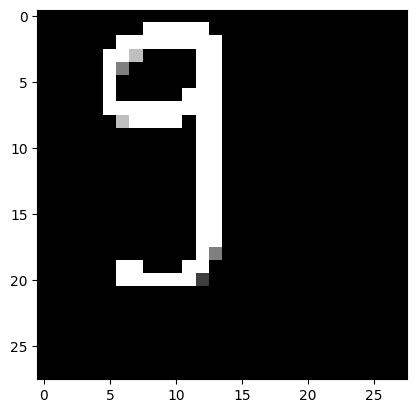

In [48]:
img_arr = np.array(json.load(open('img.json')), dtype=np.uint8)
img_arr.shape
print_pixel_grid(img_arr)
_ = plt.imshow(img_arr, cmap='gray')

In [49]:
batch = transform(img_arr).unsqueeze(0)
batch.shape
batch.min(), batch.max()

torch.Size([1, 1, 28, 28])

(tensor(-1.), tensor(1.))

In [50]:
_ = model.eval()
with torch.no_grad():
  outputs = model(batch)
  torch.max(outputs, dim=1).indices[0].item()

2